In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import pandas as pd

file_path = '/content/drive/My Drive/Colab Notebooks/XXXXXXXXXXXXXXXX'  # Update with the correct path if needed
try:
    df = pd.read_csv(file_path)
    print("File loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print(f"File not found at {file_path}. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred: {e}")

File not found at /content/drive/My Drive/Colab Notebooks/XXXXXXXXXXXXXXXX. Please check the path and try again.


In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("neuromusic/avocado-prices")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'avocado-prices' dataset.
Path to dataset files: /kaggle/input/avocado-prices


Loading dataset from: /kaggle/input/avocado-prices/avocado.csv

--- Dataset Information ---
Shape of the dataset: (18249, 14)

First 5 rows:


,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany



Column information and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB

Descriptive statistics:


,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000



Missing values before cleaning:


,0
Unnamed: 0,0
Date,0
AveragePrice,0
Total Volume,0
4046,0
4225,0
4770,0
Total Bags,0
Small Bags,0
Large Bags,0



--- Handling Missing Values ---
Removed 0 rows with missing values.
New shape after dropping missing values: (18249, 14)

Missing values after cleaning:


,0
Unnamed: 0,0
Date,0
AveragePrice,0
Total Volume,0
4046,0
4225,0
4770,0
Total Bags,0
Small Bags,0
Large Bags,0



Created 'Estimated Revenue' column (Total Volume * AveragePrice).
Note: 'Profit' cannot be accurately calculated without cost data.

--- Scatter Plot: AveragePrice vs Estimated Revenue ---


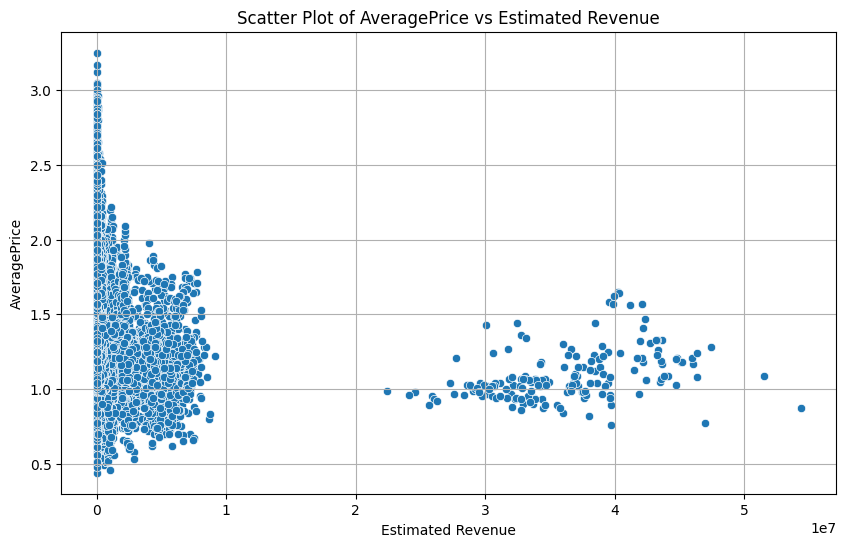


--- Correlation Heatmap ---


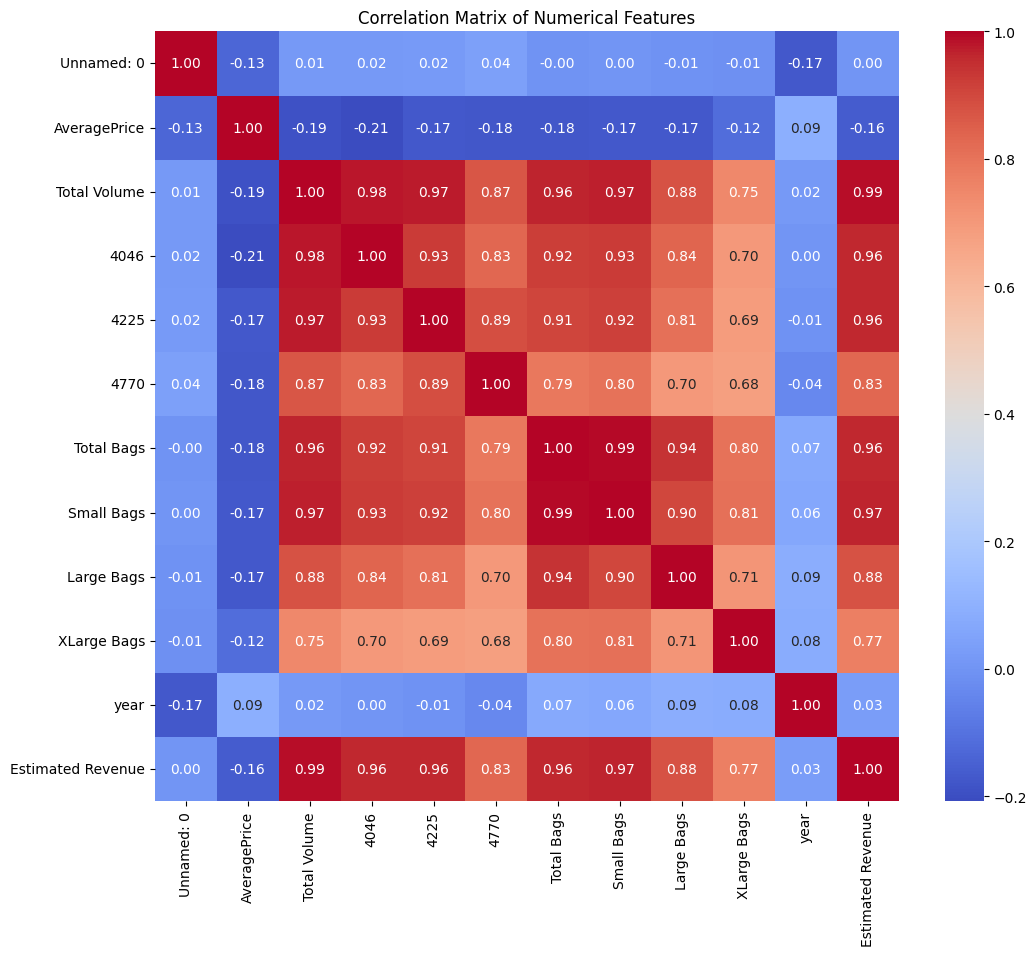


--- Identifying High Correlation Pairs ---
Columns with absolute correlation greater than 0.7:
- Total Volume and 4046: 0.98
- Total Volume and 4225: 0.97
- Total Volume and 4770: 0.87
- Total Volume and Total Bags: 0.96
- Total Volume and Small Bags: 0.97
- Total Volume and Large Bags: 0.88
- Total Volume and XLarge Bags: 0.75
- Total Volume and Estimated Revenue: 0.99
- 4046 and 4225: 0.93
- 4046 and 4770: 0.83
- 4046 and Total Bags: 0.92
- 4046 and Small Bags: 0.93
- 4046 and Large Bags: 0.84
- 4046 and Estimated Revenue: 0.96
- 4225 and 4770: 0.89
- 4225 and Total Bags: 0.91
- 4225 and Small Bags: 0.92
- 4225 and Large Bags: 0.81
- 4225 and Estimated Revenue: 0.96
- 4770 and Total Bags: 0.79
- 4770 and Small Bags: 0.80
- 4770 and Estimated Revenue: 0.83
- Total Bags and Small Bags: 0.99
- Total Bags and Large Bags: 0.94
- Total Bags and XLarge Bags: 0.80
- Total Bags and Estimated Revenue: 0.96
- Small Bags and Large Bags: 0.90
- Small Bags and XLarge Bags: 0.81
- Small Bags and E

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Assuming 'path' is already defined from the previous cell execution by kagglehub
# path = '/root/.cache/kagglehub/datasets/neuromusic/avocado-prices/versions/1'

# Find the CSV file in the downloaded directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if not csv_files:
    print("No CSV file found in the dataset directory.")
else:
    file_name = csv_files[0] # Assuming there's only one main CSV
    file_path = os.path.join(path, file_name)

    print(f"Loading dataset from: {file_path}")
    df = pd.read_csv(file_path)

    # 1. Tell me about the file
    print("\n--- Dataset Information ---")
    print(f"Shape of the dataset: {df.shape}")
    print("\nFirst 5 rows:")
    display(df.head())
    print("\nColumn information and data types:")
    df.info()
    print("\nDescriptive statistics:")
    display(df.describe())
    print("\nMissing values before cleaning:")
    display(df.isnull().sum())

    # 2. Remove rows with missing values
    initial_rows = df.shape[0]
    df.dropna(inplace=True)
    rows_after_dropna = df.shape[0]
    print(f"\n--- Handling Missing Values ---")
    print(f"Removed {initial_rows - rows_after_dropna} rows with missing values.")
    print(f"New shape after dropping missing values: {df.shape}")
    print("\nMissing values after cleaning:")
    display(df.isnull().sum())

    # Check if 'Total Volume' and 'AveragePrice' columns exist to create 'Estimated Revenue'
    x_col_for_scatter = None
    y_col_for_scatter = None

    if 'Total Volume' in df.columns and 'AveragePrice' in df.columns:
        # Create an estimated revenue column
        df['Estimated Revenue'] = df['Total Volume'] * df['AveragePrice']
        print("\nCreated 'Estimated Revenue' column (Total Volume * AveragePrice).")
        print("Note: 'Profit' cannot be accurately calculated without cost data.")
        x_col_for_scatter = 'Estimated Revenue'
        y_col_for_scatter = 'AveragePrice'
    else:
        print("\n'Total Volume' or 'AveragePrice' columns not found. Cannot create 'Estimated Revenue'.")
        # Fallback to other numerical columns if possible for scatter plot
        numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
        if len(numerical_cols) >= 2:
            x_col_for_scatter = numerical_cols[0]
            y_col_for_scatter = numerical_cols[1]
            print(f"Using '{x_col_for_scatter}' and '{y_col_for_scatter}' for scatter plot as fallback.")
        else:
            print("Not enough numerical columns to create a scatter plot.")

    # 3. Create a Scatter plot (using derived or available columns)
    if x_col_for_scatter and y_col_for_scatter:
        print(f"\n--- Scatter Plot: {y_col_for_scatter} vs {x_col_for_scatter} ---")
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=df[x_col_for_scatter], y=df[y_col_for_scatter])
        plt.title(f'Scatter Plot of {y_col_for_scatter} vs {x_col_for_scatter}')
        plt.xlabel(x_col_for_scatter)
        plt.ylabel(y_col_for_scatter)
        plt.grid(True)
        plt.show()
    else:
        print("\nCould not generate scatter plot due to insufficient numerical data.")

    # 4. Visualize the relationship between columns (Correlation Heatmap)
    print("\n--- Correlation Heatmap ---")
    # Select only numerical columns for correlation matrix
    numerical_df = df.select_dtypes(include=np.number)
    if not numerical_df.empty:
        plt.figure(figsize=(12, 10))
        sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('Correlation Matrix of Numerical Features')
        plt.show()
    else:
        print("No numerical columns found to generate a correlation heatmap.")


    # 5. Identify columns with high correlation
    print("\n--- Identifying High Correlation Pairs ---")
    if not numerical_df.empty:
        correlation_matrix = numerical_df.corr().abs()
        # Select upper triangle of correlation matrix
        upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

        # Find features with correlation greater than 0.7 (threshold can be adjusted)
        high_corr_pairs = []
        threshold = 0.7
        for i in range(len(upper_tri.columns)):
            for j in range(i + 1, len(upper_tri.columns)):
                if not pd.isna(upper_tri.iloc[i, j]) and upper_tri.iloc[i, j] > threshold:
                    high_corr_pairs.append((upper_tri.columns[i], upper_tri.columns[j], upper_tri.iloc[i, j]))

        if high_corr_pairs:
            print(f"Columns with absolute correlation greater than {threshold}:")
            for col1, col2, corr_val in high_corr_pairs:
                print(f"- {col1} and {col2}: {corr_val:.2f}")
        else:
            print(f"No columns found with absolute correlation greater than {threshold}.")
    else:
        print("No numerical columns available to identify high correlation pairs.")

### Machine Learning Model: Predicting Avocado AveragePrice

In [14]:
# 1. Data Preparation for Machine Learning

# Convert 'Date' to datetime objects and extract features
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Drop the original 'Date' column and 'Unnamed: 0' (if it exists and is an index column)
columns_to_drop = ['Date', 'Unnamed: 0']
df_ml = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

# Handle categorical variables ('type' and 'region') using one-hot encoding
df_ml = pd.get_dummies(df_ml, columns=['type', 'region'], drop_first=True)

# Define features (X) and target (y)
X = df_ml.drop('AveragePrice', axis=1)
y = df_ml['AveragePrice']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData split complete:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Features (X) shape: (18249, 67)
Target (y) shape: (18249,)

Data split complete:
X_train shape: (14599, 67)
X_test shape: (3650, 67)
y_train shape: (14599,)
y_test shape: (3650,)


In [15]:
# 2. Train a Linear Regression Model

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

# Make predictions on the test set
y_pred = model.predict(X_test)


Linear Regression model trained successfully.



Model Evaluation:
Mean Squared Error (MSE): 0.07
Root Mean Squared Error (RMSE): 0.26
R-squared (R2 Score): 0.59


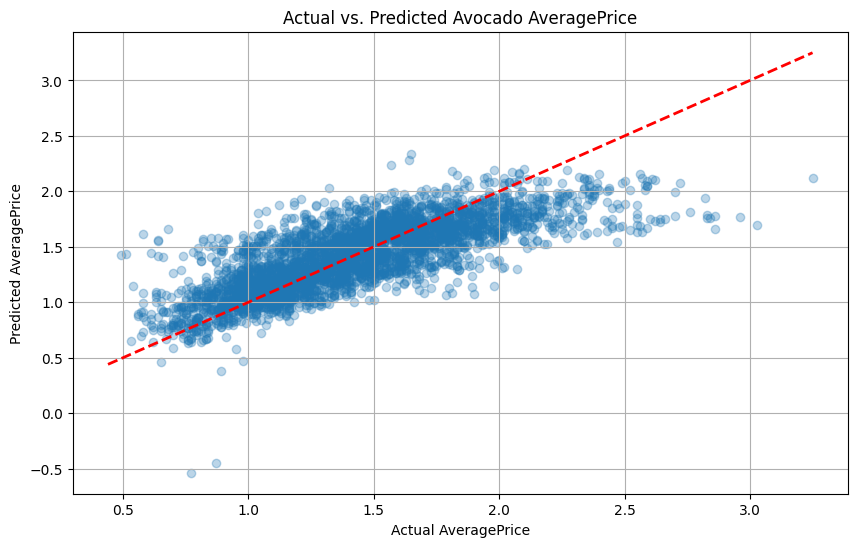

In [16]:
# 3. Evaluate the Model

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error

# Calculate R-squared (R2 Score)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

# Visualize actual vs. predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel("Actual AveragePrice")
plt.ylabel("Predicted AveragePrice")
plt.title("Actual vs. Predicted Avocado AveragePrice")
plt.grid(True)
plt.show()

### Generating Random Data Points to Test the Model

In [17]:
# Generate 100 random data points to test the model

# Get column names and their ranges from X_train
feature_columns = X_train.columns

generated_data = []

# Identify numerical and one-hot encoded categorical columns
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
one_hot_type_cols = [col for col in feature_columns if col.startswith('type_')]
one_hot_region_cols = [col for col in feature_columns if col.startswith('region_')]

for _ in range(100):
    sample = {}
    # Generate random values for numerical features based on X_train's min/max
    for col in numerical_cols:
        # Exclude 'year', 'Month', 'Day', 'DayOfWeek' from this generic numerical generation
        # as they have specific integer ranges or might be handled differently
        if col not in ['year', 'Month', 'Day', 'DayOfWeek']:
            min_val = X_train[col].min()
            max_val = X_train[col].max()
            sample[col] = np.random.uniform(min_val, max_val)

    # Handle specific integer-based numerical columns
    sample['year'] = np.random.randint(X_train['year'].min(), X_train['year'].max() + 1)
    sample['Month'] = np.random.randint(1, 13)
    sample['Day'] = np.random.randint(1, 32)
    sample['DayOfWeek'] = np.random.randint(0, 7)

    # Generate random values for 'type_organic' (0 or 1)
    if 'type_organic' in one_hot_type_cols:
        sample['type_organic'] = np.random.choice([0, 1])

    # Generate random values for one-hot encoded region columns
    # Ensure only one region is active (1) and others are 0
    if one_hot_region_cols:
        # Initialize all region columns to 0
        for region_col in one_hot_region_cols:
            sample[region_col] = 0
        # Randomly choose one region to be 1
        chosen_region_col = np.random.choice(one_hot_region_cols)
        sample[chosen_region_col] = 1

    generated_data.append(sample)

# Create a DataFrame from the generated data
X_generated = pd.DataFrame(generated_data)

# Reindex to ensure all columns from X_train are present and in the correct order
# Fill any missing columns (e.g., if a region wasn't picked) with 0
X_generated = X_generated.reindex(columns=feature_columns, fill_value=0)

print("Generated 100 random data points.")
display(X_generated.head())

# Predict prices using the trained model
predictions_generated = model.predict(X_generated)

# Add predictions to the generated DataFrame for display
X_generated['Predicted_AveragePrice'] = predictions_generated

print("\nPredictions for generated data points:")
display(X_generated[['year', 'Month', 'Day', 'Total Volume', 'Predicted_AveragePrice']].head(10))


Generated 100 random data points.


,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year,Estimated Revenue,...,region_SouthCarolina,region_SouthCentral,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico
0,3.287391e+07,1.392286e+06,1.150337e+07,4.974527e+05,1.079445e+07,6.034116e+06,1.834097e+06,110425.385935,2016,4.200521e+07,...,0,0,0,0,0,0,0,0,0,0
1,4.199790e+07,1.030675e+07,6.955206e+06,1.562640e+06,1.319463e+07,6.486801e+06,3.833285e+06,352939.409239,2015,1.411453e+07,...,0,0,0,1,0,0,0,0,0,0
2,4.064302e+06,1.695742e+07,1.883405e+07,2.102266e+05,3.289258e+06,2.454904e+06,3.587804e+06,8164.273721,2018,4.793000e+07,...,0,0,0,0,0,0,0,0,0,0
3,1.148819e+07,8.204223e+06,5.643817e+06,3.449394e+05,4.178457e+06,8.235460e+06,3.838704e+06,92950.669689,2017,7.143716e+06,...,0,0,0,0,0,0,0,0,0,0
4,4.462068e+07,6.777034e+06,1.764626e+07,2.332392e+06,1.332674e+06,2.516651e+06,2.782540e+06,37322.181002,2015,1.062859e+07,...,0,0,0,0,0,0,0,0,0,0



Predictions for generated data points:


,year,Month,Day,Total Volume,Predicted_AveragePrice
0,2016,6,1,3.287391e+07,-112192.173540
1,2015,12,15,4.199790e+07,-100437.083801
2,2018,9,20,4.064302e+06,109605.716926
3,2017,8,4,1.148819e+07,318591.456775
4,2015,4,25,4.462068e+07,159997.338258
5,2018,7,25,3.683668e+07,-6170.540772
6,2018,5,13,2.593552e+07,-450468.806229
7,2015,5,15,2.327799e+07,-172965.566566
8,2016,5,18,1.714682e+07,-149099.595269
9,2018,2,14,2.792388e+06,-96964.158728


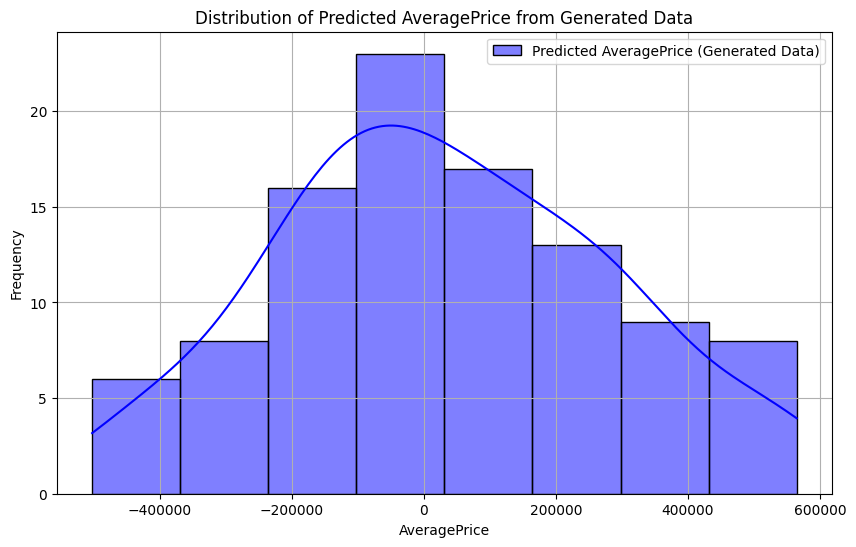

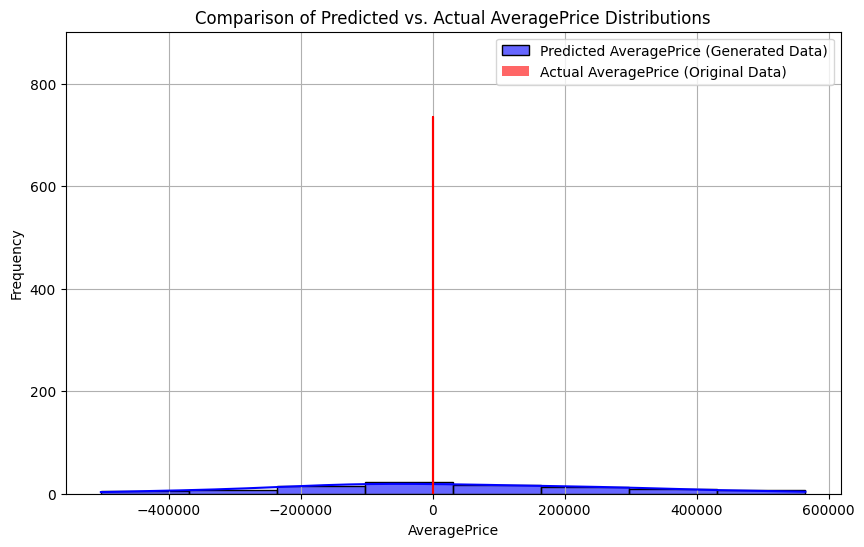

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prediction on random data (already performed in the previous cell)
# 'predictions_generated' and 'X_generated['Predicted_AveragePrice']' are already available.

# 2. Visualize the predicted AveragePrice from the generated data
plt.figure(figsize=(10, 6))
sns.histplot(X_generated['Predicted_AveragePrice'], kde=True, color='blue', label='Predicted AveragePrice (Generated Data)')
plt.title('Distribution of Predicted AveragePrice from Generated Data')
plt.xlabel('AveragePrice')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# 3. Compare with the original dataset's AveragePrice
plt.figure(figsize=(10, 6))
sns.histplot(X_generated['Predicted_AveragePrice'], kde=True, color='blue', label='Predicted AveragePrice (Generated Data)', alpha=0.6)
sns.histplot(df['AveragePrice'], kde=True, color='red', label='Actual AveragePrice (Original Data)', alpha=0.6)
plt.title('Comparison of Predicted vs. Actual AveragePrice Distributions')
plt.xlabel('AveragePrice')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()